
#**Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

##**Edición 2026**

---
## Trabajo práctico entregable - Parte 2

## Grupo 3:


*   BAGGINI, Mariano
*   DA SILVA, Rocio
*   GRUZYCKI, Sergio
*   NEDEL, Agustina  



In [1]:
import io
import math
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_context('talk')

### Lectura del dataset y Limpieza de datos

In [2]:
url = 'https://raw.githubusercontent.com/DiploDatos/AnalisisyVisualizacion/master/sysarmy_survey_2026_processed.csv'
df = pd.read_csv(url)
df_raw = df.copy()
df_raw.head(3)

,work_province,work_dedication,work_contract_type,salary_monthly_BRUTO,salary_monthly_NETO,salary_in_usd,salary_last_dollar_value,salary_has_bonus,salary_bonus_tied_to,salary_inflation_adjustment,...,salary_on_call_duty_charge,aclara_el_numero_que_ingresaste_en_el_campo_anterior,salir_o_seguir_contestando_sobre_estudios,profile_age,profile_gender,profile_previous_survey,company_best_companies,sueldo_dolarizado,work_seniority,_sal
0,Mendoza,Full-Time,Staff (planta permanente),3000000.0,2400000.0,Mi sueldo está dolarizado (pero cobro en moned...,1300,No,Performance individual,No,...,NaN,NaN,NaN,45,Mujer Cis,Sí,NaN,True,Senior,3000000.0
1,Santa Fe,Full-Time,Contractor,5000000.0,5000000.0,Cobro todo el salario en dólares,1400,No,No recibo bono,No,...,NaN,NaN,NaN,50,Mujer Cis,Sí,NaN,True,Senior,5000000.0
2,Buenos Aires,Full-Time,Tercerizado (trabajo a través de consultora o ...,4600000.0,3600000.0,Cobro parte del salario en dólares,1436,No,No recibo bono,Uno,...,0.0,Porcentaje de mi sueldo bruto,Terminar encuesta,36,Mujer Cis,Sí,NaN,True,Senior,4600000.0


In [3]:
# Columnas a utilizar en el analisis
relevant_columns = ['tools_programming_languages', 'salary_monthly_NETO',
                    'work_dedication', 'work_seniority']

1.5 Exploración inicial de los datos

In [4]:
# Observación general de los datos
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4939 entries, 0 to 4938
Data columns (total 60 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   work_province                                         4939 non-null   object 
 1   work_dedication                                       4939 non-null   object 
 2   work_contract_type                                    4939 non-null   object 
 3   salary_monthly_BRUTO                                  4939 non-null   float64
 4   salary_monthly_NETO                                   4717 non-null   float64
 5   salary_in_usd                                         1583 non-null   object 
 6   salary_last_dollar_value                              1028 non-null   object 
 7   salary_has_bonus                                      4939 non-null   object 
 8   salary_bonus_tied_to                                  4938

In [5]:
# Resumen estadístico de variables numéricas
df_raw.describe()

,salary_monthly_BRUTO,salary_monthly_NETO,salary_percentage_inflation_adjustment,salary_comparison_last_semester,salary_satisfaction,profile_years_experience,work_years_in_company,work_years_in_current_position,work_people_in_charge_of,company_days_in_the_office,company_recommended,tools_copilotchatgpt,salary_on_call_duty_charge,profile_age,_sal
count,4.939000e+03,4.717000e+03,4939.000000,4939.000000,4939.000000,4939.000000,4939.000000,4939.000000,4939.000000,4939.000000,4939.000000,4939.000000,1.140000e+03,4939.000000,4.939000e+03
mean,3.876029e+06,3.599215e+06,16.810541,2.475805,2.491193,10.112371,4.515084,3.604576,3.297226,0.911318,6.442397,3.851589,1.783156e+04,37.505568,3.876029e+06
std,2.492699e+06,1.183755e+07,569.136871,0.833417,0.890111,8.262828,5.317266,4.007707,40.883588,1.260931,2.798569,1.315562,1.207110e+05,18.643457,2.492699e+06
min,2.000000e+05,1.600000e+00,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,16.000000,2.000000e+05
25%,2.166336e+06,1.850000e+06,0.000000,2.000000,2.000000,4.000000,1.000000,1.000000,0.000000,0.000000,5.000000,3.000000,0.000000e+00,30.000000,2.166336e+06
50%,3.268000e+06,2.750000e+06,6.000000,3.000000,3.000000,7.000000,3.000000,3.000000,0.000000,0.000000,7.000000,4.000000,0.000000e+00,36.000000,3.268000e+06
75%,4.944960e+06,4.000000e+06,12.000000,3.000000,3.000000,15.000000,5.000000,5.000000,1.000000,2.000000,8.000000,5.000000,0.000000e+00,43.000000,4.944960e+06
max,2.000000e+07,6.533882e+08,40000.000000,4.000000,4.000000,48.000000,43.000000,40.000000,2500.000000,5.000000,10.000000,5.000000,1.800000e+06,999.000000,2.000000e+07


In [6]:
# Descripción de variables categóricas
df_raw.describe(include="object")

,work_province,work_dedication,work_contract_type,salary_in_usd,salary_last_dollar_value,salary_has_bonus,salary_bonus_tied_to,salary_inflation_adjustment,salary_month_last_inflation_adjustment,salary_benefit,...,profile_hours_per_day,company_selection_process,salir_o_seguir_contestando_sobre_las_guardias1,work_on_call_duty,aclara_el_numero_que_ingresaste_en_el_campo_anterior,salir_o_seguir_contestando_sobre_estudios,profile_gender,profile_previous_survey,company_best_companies,work_seniority
count,4939,4939,4939,1583,1028,4939,4938,4939,4939,4939,...,1280,1282,1298,1140,1140,1140,4938,4939,1600,4939
unique,24,2,5,3,253,5,203,5,13,1734,...,6,4,3,3,3,3,7,2,1010,3
top,Ciudad Autónoma de Buenos Aires,Full-Time,Staff (planta permanente),Cobro todo el salario en dólares,1450,No,No recibo bono,Uno,No tuve,Ninguna de las anteriores,...,Menos de 2 horas,"Si me interesa la empresa, invierto todo el ti...",Terminar encuesta,No,Porcentaje de mi sueldo bruto,Responder sobre mis estudios,Hombre Cis,Sí,Mercado Libre,Senior
freq,2476,4724,3526,737,154,2876,2835,1644,1081,798,...,367,509,999,654,626,579,3861,3977,76,2892


In [7]:
# Estudio del contenido en las columnas de interés. Verificación de types y nulls
df_raw[relevant_columns].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4939 entries, 0 to 4938
Data columns (total 4 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   tools_programming_languages  4938 non-null   object 
 1   salary_monthly_NETO          4717 non-null   float64
 2   work_dedication              4939 non-null   object 
 3   work_seniority               4939 non-null   object 
dtypes: float64(1), object(3)
memory usage: 154.5+ KB


2. Selección de filas relevantes (Limpieza de datos)

*   Nulos en las columnas de interés
*   Duplicados
*   Outliers sobre el salario neto

In [8]:
# Limpieza sobre columnas relevantes
df_raw = df_raw.drop_duplicates()
df_raw = df_raw.dropna(subset=relevant_columns)
df_raw[relevant_columns].info()

<class 'pandas.core.frame.DataFrame'>
Index: 4715 entries, 0 to 4938
Data columns (total 4 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   tools_programming_languages  4715 non-null   object 
 1   salary_monthly_NETO          4715 non-null   float64
 2   work_dedication              4715 non-null   object 
 3   work_seniority               4715 non-null   object 
dtypes: float64(1), object(3)
memory usage: 184.2+ KB


Se optó por filtrar los valores atípicos utilizando percentiles

In [9]:
# Limpieza de extremos con percentiles (1% superior e inferior)
p01 = df_raw['salary_monthly_NETO'].quantile(0.01)
p99 = df_raw['salary_monthly_NETO'].quantile(0.99)

df_bounded = df_raw[
    (df_raw['salary_monthly_NETO'] >= p01) &
    (df_raw['salary_monthly_NETO'] <= p99)
].copy()

In [10]:
df_bounded[["salary_monthly_BRUTO", "salary_monthly_NETO"]].describe()

,salary_monthly_BRUTO,salary_monthly_NETO
count,4.619000e+03,4.619000e+03
mean,3.778979e+06,3.180796e+06
std,2.292394e+06,1.862286e+06
min,2.000000e+05,3.900000e+05
25%,2.150522e+06,1.888430e+06
50%,3.200000e+06,2.750000e+06
75%,4.834034e+06,4.000000e+06
max,1.700000e+07,1.182000e+07


In [11]:
# Verificación BRUTO > NETO
consistency = df_bounded.salary_monthly_BRUTO > df_bounded.salary_monthly_NETO

# Contar la cantidad de veces que se cumple la condición
count_true = consistency.sum()
count_false = (~consistency).sum()

print(f"Filas donde BRUTO > NETO: {count_true}")
print(f"Filas donde BRUTO <= NETO: {count_false}")

Filas donde BRUTO > NETO: 3977
Filas donde BRUTO <= NETO: 642


In [12]:
# Agregar flagger (booleano)
df_bounded['bruto_mayor_que_neto'] = consistency

# Eliminar filas con ratio > 1.5: Errores evidentes
df_bounded = df_bounded[
    df_bounded['salary_monthly_NETO'] / df_bounded['salary_monthly_BRUTO'] < 1.5]

df_bounded[["salary_monthly_BRUTO", "salary_monthly_NETO"]].describe()

,salary_monthly_BRUTO,salary_monthly_NETO
count,4.581000e+03,4.581000e+03
mean,3.801095e+06,3.179284e+06
std,2.288024e+06,1.867186e+06
min,4.000000e+05,3.900000e+05
25%,2.198917e+06,1.880000e+06
50%,3.248203e+06,2.736180e+06
75%,4.883219e+06,4.000000e+06
max,1.700000e+07,1.182000e+07


In [13]:
# Se considera la subpoblacion con dedicacion Full-Time
df_bounded.groupby("work_dedication")["salary_monthly_NETO"].describe()

# Eliminar filas con work_dedication Part time en un nuevo df restringido
df_restricted = df_bounded.drop(df_bounded[df_bounded["work_dedication"] == "Part-Time"].index)
df_restricted["salary_monthly_NETO"].describe()

,salary_monthly_NETO
count,4.391000e+03
mean,3.231857e+06
std,1.863610e+06
min,3.900000e+05
25%,1.921388e+06
50%,2.800000e+06
75%,4.000000e+06
max,1.182000e+07


In [14]:
df_restricted.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4391 entries, 0 to 4938
Data columns (total 61 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   work_province                                         4391 non-null   object 
 1   work_dedication                                       4391 non-null   object 
 2   work_contract_type                                    4391 non-null   object 
 3   salary_monthly_BRUTO                                  4391 non-null   float64
 4   salary_monthly_NETO                                   4391 non-null   float64
 5   salary_in_usd                                         1327 non-null   object 
 6   salary_last_dollar_value                              880 non-null    object 
 7   salary_has_bonus                                      4391 non-null   object 
 8   salary_bonus_tied_to                                  4391 non-

#### Resumen de lo obtenido hasta aquí:

En este punto se tiene un data set libre de duplicados, nulos y outliers en las columnas de interés, con un rango salarial neto entre los cuantiles 1% y 99%, restringido a dedicación Full-Time. Se identificaron los casos en que NETO >= BRUTO. Además, se admite la posibilidad de segmentar el estudio a seniorities específicas (Junior, Semi-senior y Senior). Se optó por no segmentar el estudio en función del puesto, a fin de incluir una diversidad de lenguajes mayor en el estudio.  

#Creación de Grupo A y Grupo B

In [15]:
df_restricted.profile_gender.unique()

array(['Mujer Cis', 'Hombre Cis', 'Prefiero no decir', 'Trans', 'Queer',
       'No binarie', 'Agénero', nan], dtype=object)

In [16]:
df_restricted.loc[:,'profile_g'] = df_restricted.profile_gender.replace({'Hombre Cis': 'Varón cis','Mujer Cis': 'Mujer cis','Queer':'Diversidades','Trans':'Diversidades','Queer':'Diversidades','Lesbiana':'Diversidades','Agénero':'Diversidades'}).fillna(False)

In [17]:
alpha = 0.05

In [18]:
is_man = df_restricted.profile_g == 'Varón cis'
is_woman = df_restricted.profile_g == 'Mujer cis'

In [19]:
groupA = df_restricted[(15000000>df_restricted.salary_monthly_NETO)&(df_restricted.salary_monthly_NETO > 100000) & is_man].salary_monthly_NETO
groupB  = df_restricted[(df_restricted.salary_monthly_NETO > 100000) & is_woman].salary_monthly_NETO


In [20]:
print(f"Mean: {groupA.mean()}")
print(f"Median: {groupA.median()}")
print(f"Standard Deviation: {groupA.std()}")

Mean: 3344698.803188027
Median: 2903939.0
Standard Deviation: 1912792.6723752182


In [21]:
print(f"Mean: {groupB.mean()}")
print(f"Median: {groupB.median()}")
print(f"Standard Deviation: {groupB.std()}")

Mean: 2761057.0305427248
Median: 2400000.0
Standard Deviation: 1507820.5560135248


Text(0.5, 0, 'Salary')

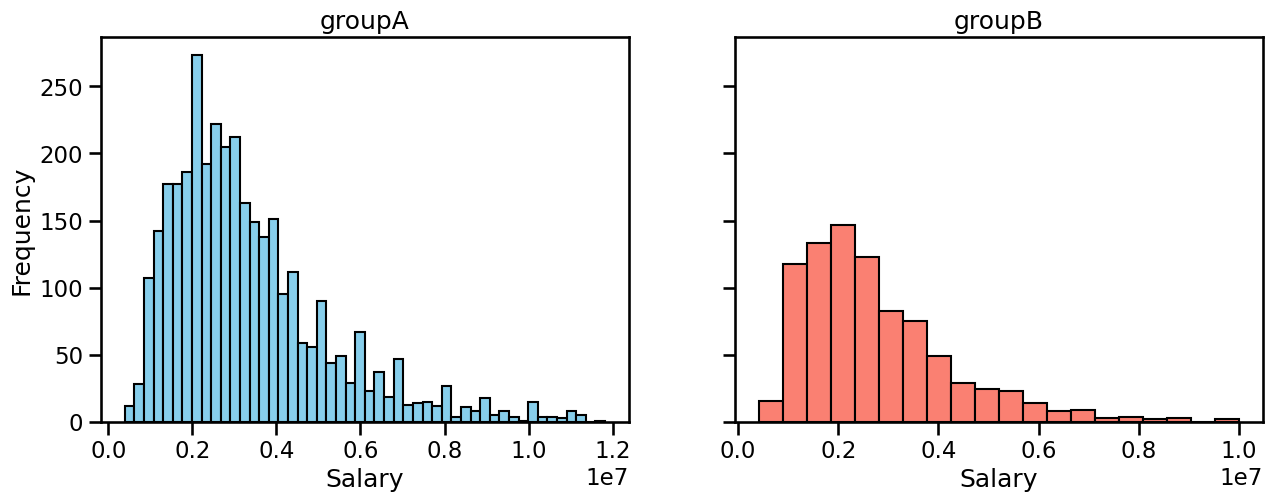

In [22]:
# Create the histograms
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)  # 1 row, 3 columns

# Plot each group on a separate subplot
axes[0].hist(groupA, bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('groupA')
axes[0].set_xlabel('Salary')
axes[0].set_ylabel('Frequency')

axes[1].hist(groupB, bins=20, color='salmon', edgecolor='black')
axes[1].set_title('groupB')
axes[1].set_xlabel('Salary')

# Ejercicio 1: Estimación

Consigna: Calcular una estimación puntual y un intervalo de confianza de nivel (1-alpha) para la resta entre la media del salario Neto para Hombres y la media del salario Neto para mujeres (diferencia de las medias entre el grupoA y grupoB). ¿Cómo se relaciona este intervalo de confianza con el test de hipótesis para diferencia de medias?

In [23]:
salarios_hombres = groupA
salarios_mujeres = groupB

# Calcular medias y desviaciones estándar
x_h = np.mean(salarios_hombres)  # Media hombres
x_m = np.mean(salarios_mujeres)  # Media mujeres
s_h = np.std(salarios_hombres, ddof=1)  # Desviación estándar hombres
s_m = np.std(salarios_mujeres, ddof=1)  # Desviación estándar mujeres
n_h = len(salarios_hombres)  # Tamaño muestral hombres
n_m = len(salarios_mujeres)  # Tamaño muestral mujeres

# Estimación puntual
diff_medias = x_h - x_m
print(f"Estimación puntual de la diferencia de medias (Grupo A - Grupo B): {diff_medias:.2f}")

# Intervalo de confianza usando t de Welch
se_diff = np.sqrt((s_h**2 / n_h) + (s_m**2 / n_m))

# Grados de libertad de Welch
gl = ((s_h**2 / n_h + s_m**2 / n_m)**2) / (
    ((s_h**2 / n_h)**2 / (n_h - 1)) + ((s_m**2 / n_m)**2 / (n_m - 1))
)

# Valor crítico
t_crit = stats.t.ppf(1 - alpha / 2, gl)

# Margen de error
margen_error = t_crit * se_diff

# Intervalo de confianza
ic_inferior = diff_medias - margen_error
ic_superior = diff_medias + margen_error

print(f"Intervalo de confianza al {100*(1-alpha)}%: ({ic_inferior:.2f}, {ic_superior:.2f})")

Estimación puntual de la diferencia de medias (Grupo A - Grupo B): 583641.77
Intervalo de confianza al 95.0%: (464517.65, 702765.90)


La estimación puntual de la diferencia entre la media del salario neto de hombres y la de mujeres es la resta entre ambas medias muestrales. Esta medida indica la brecha salarial promedio observada en la muestra.

A su vez, el intervalo de confianza permite estimar entre qué valores podría encontrarse la verdadera diferencia de medias en la población.

Su relación con el test de hipótesis es que, para contrastar si existe o no diferencia significativa entre ambas medias, se analiza si el valor 0 está contenido en el intervalo:

$H_0$: la media del salario neto de los hombres es igual a la media del salario neto de las mujeres.

$H_1$: la media del salario neto de los hombres es distinta de la media del salario neto de las mujeres

El test de hipótesis verifica si la diferencia entre medias puede considerarse igual a 0. El intervalo de confianza muestra los valores posibles para esa diferencia.

In [24]:
diferencia_abs = x_h - x_m
diferencia_pct = (diferencia_abs / x_m) * 100

print(f"Promedio hombres: {x_h:.2f}")
print(f"Promedio mujeres: {x_m:.2f}")
print(f"Diferencia absoluta: {diferencia_abs:.2f}")
print(f"Diferencia porcentual: {diferencia_pct:.2f}%")

Promedio hombres: 3344698.80
Promedio mujeres: 2761057.03
Diferencia absoluta: 583641.77
Diferencia porcentual: 21.14%


# Ejercicio 2: Test de hipótesis


### 2.1 Formalización

Describir formalmente los distintos componentes de un test de hipótesis para comprobar si la distribución de los salarios es distinta entre los grupos A y B.

**Hipótesis Nula**

$H_0= μ_A - μ_B = 0$

**Hipótesis Alternativa**

$H_1= μ_A - μ_B ≠ 0$

**Estadístico (Pivote)**
  * Identificar el estadístico

    El estadístico de prueba es la diferencia de medias muestrales estandarizada, utilizando el error estándar conjunto de ambas muestras.

  * Escribir qué distribución tiene bajo $H_0$
  
    Dado que no se asume igualdad de varianzas, el estadístico sigue una distribución t de Student con grados de libertad aproximados según el método de Welch.

### 2.2 P-valor

1. Calcule el p-valor y decida si rechazar o no la hipótesis nula.
2. Interprete el resultado.

Links útiles:
* [Test de hipótesis usando scipy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html)
* [Test de Welch](http://daniellakens.blogspot.com/2015/01/always-use-welchs-t-test-instead-of.html)

In [25]:
# Test de Welch
t_stat, p_valor = stats.ttest_ind(groupA, groupB, equal_var=False)

print(f"Estadístico t: {t_stat:.4f}")
print(f"p-valor: {p_valor:.6f}")

if p_valor < alpha:
    print("Se rechaza H0")
else:
    print("No se rechaza H0")

Estadístico t: 9.6098
p-valor: 0.000000
Se rechaza H0


Como el p-valor es menor que el nivel de significación
alpha=0.05, se rechaza la hipótesis nula. Por lo tanto, hay evidencia estadísticamente significativa para afirmar que la media del salario neto difiere entre el grupo A y el grupo B


### [Opcional] 2.3 Potencia del test

Nuestra muestra, ¿era lo suficientemente grande para detectar si existe o no una diferencia entre los grupos?

1. Utilice la función `tt_ind_solve_power` para calcular el tamaño necesario de la muestra para un poder estadístico de 0.8, 0.9 y 0.95, asumiendo una significancia estadística de 0.05.
2. ¿Cómo intepretan el poder estadístico de un test? Dado su conocimiento de dominio sobre los datos, ¿les parece que esta muestra es lo suficientemente grande para ser representativo de la tendencia general? ¿y para utilizarlo en un juicio penal contra una empresa XX por una causa de discriminación?

[Documentación](https://www.statsmodels.org/stable/generated/statsmodels.stats.power.tt_ind_solve_power.html)

NOTA: este análisis debería hacerse ANTES de recolectar los datos.

In [26]:
from statsmodels.stats.power import tt_ind_solve_power

In [27]:
effect_size = (groupA.mean() - groupB.mean()) / groupB.std()
# nobs1=None  - What we want to know
alpha = 0.05
ratio = len(groupB) / len(groupA)
power= 0.8

In [28]:
tt_ind_solve_power(effect_size=effect_size, alpha=alpha,power=power,  ratio=ratio)

262.0808489321344

## Ejercicio 3: Comunicación y visualización

**Consigna:** Seleccionen un resultado que les parezca relevante a partir de alguno de los ejercicios del entregable. Diseñe e implemente una comunicación en base a este mensaje, en un archivo PDF.

Elija las palabras y visualización más adecuada para que la comunicación sea entendible, efectiva y se dapte a UNA de las siguientes situaciones:

1. Una sección en un artículo de difusión a presentar como parte de una organización sin fines de lucro.
No más de 1 página A4 (o dos si los gráficos son muy grandes).
  1. Ejemplo: Alguna de las secciones [Los ecosistemas de emprendimiento de América Latina y el Caribe frente al COVID-19: Impactos, necesidades y recomendaciones](https://publications.iadb.org/es/los-ecosistemas-de-emprendimiento-de-america-latina-y-el-caribe-frente-al-covid-19-impactos-necesidades-y-recomendaciones), por ejemplo la sección *2.2. Reacciones de los emprendedores*.
  2. Ejemplo: Alguna de las secciones de [The state of gender pay gap in 2021](https://www.payscale.com/data/gender-pay-gap?tk=carousel-ps-rc-job)
  3. Puntos clave:
    1. Simpleza de los gráficos.
    2. Comunicación en lenguaje simple a personas que no son necesariamente expertos de dominio.
    2. Selección de UNA oración sobre la que se hace énfasis.
    3. No es necesario que mencionen objetivos ni descripciones del conjunto de datos, se supone que eso ya estaría explicado en otras secciones del informe.

2. Una publicación científica o reporte técnico interno. No más de una página A4:
  2. Ejemplo: La sección de resultados de [IZA DP No. 12914: The Impact of a Minimum Wage Change on the Distribution of Wages and Household Income](https://www.iza.org/publications/dp/12914/the-impact-of-a-minimum-wage-change-on-the-distribution-of-wages-and-household-income).
  2. Ejemplo: Alguna de las secciones de [Temporary reduction in daily global CO2 emissions during the COVID-19 forced confinement](https://www.nature.com/articles/s41558-020-0797-x)
  3. Puntos clave:
    3. Nivel de detalle técnico requerido. Es necesario justificar la validez del análisis.
    4. La idea presentada puede ser más compleja. Pueden asumir que la audiencia tiene conocimiento técnico y va a analizar las visualizaciones en detalle.
    5. Pueden presentar más en detalle las limitaciones del análisis (significancia estadística, etc.)
    2. No es necesario que mencionen objetivos ni descripciones del conjunto de datos, se supone que eso ya estaría explicado en otras secciones del informe.

3. Un tweet (o post de LinkedIn) para la cuenta de su empresa consultora que hace análisis de datos. El objetivo es promocionar un análisis de datos abiertos que van a incluir en su portfolio:
  1. Ejemplo: [Comparación vacunas covid](https://twitter.com/infobeautiful/status/1381577746527236098?s=20)
  2. Ejemplo: [Tweet del BID](https://twitter.com/el_BID/status/1388508583944507396?s=20). Lo valioso de este tweet es que usaron un único número para transmitir un mensaje. Puede ser algo así, o con un gráfico muy simple.
  3. Ejemplo: [Cambio climático](https://twitter.com/UNFCCC/status/1387732156190011394?s=20) Es un muy buen ejemplo, excepto que el gráfico no se lee nada y hay que entrar a la publicación original.
  3. Ejemplo: [¿Cuánto están los programadores en las empresas?](https://www.linkedin.com/posts/denis-rothman-0b034043_tech-career-work-activity-6793861923269054464-gS6y) (No verificamos la veracidad o seriedad de la fuente).
  4. Puntos clave:
    1. Su audiencia no va a mirar la visualización por más de unos segundos, y no tiene conocimiento técnico.
  3. Tienen que incluir además una *breve* descripción de cómo obtuvieron los datos que están presentando, que no entraría en el tweet.

In [29]:
def salary_formatter_m(x, pos):
    millions = x / 1e6
    return f'{millions:.1f}M'

### Comparación Global por género


In [30]:
tabla_genero = (
    df_restricted[
        df_restricted["profile_g"].isin(["Varón cis", "Mujer cis"])
    ]
    .groupby("profile_g")["salary_monthly_NETO"]
    .agg(
        n="count",
        media="mean",
        mediana="median",
        std="std",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75)
    )
    .round(2)
)

print("Resumen salarial por género:")
print(tabla_genero)

Resumen salarial por género:
              n       media    mediana         std        q25        q75
profile_g                                                               
Mujer cis   866  2761057.03  2400000.0  1507820.56  1690750.0  3500000.0
Varón cis  3441  3344698.80  2903939.0  1912792.67  2000000.0  4200000.0


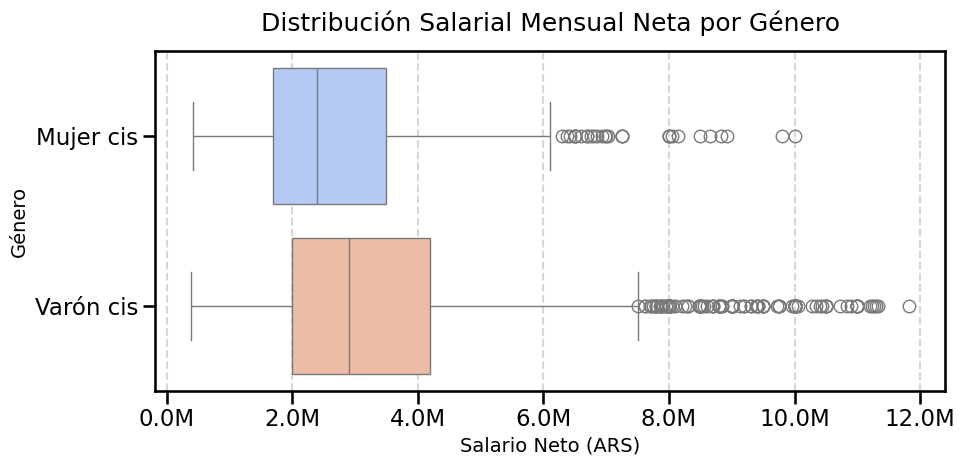

In [31]:
df_gender = df_restricted[
    df_restricted["profile_g"].isin(["Varón cis", "Mujer cis"])
].copy()

fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(
    data=df_gender,
    x="salary_monthly_NETO",
    y="profile_g",
    hue="profile_g",
    legend=False,
    palette="coolwarm",
    ax=ax
)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(salary_formatter_m))
ax.set_title("Distribución Salarial Mensual Neta por Género", fontsize=18, pad=15)
ax.set_xlabel("Salario Neto (ARS)", fontsize=14)
ax.set_ylabel("Género", fontsize=14)
ax.grid(True, axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

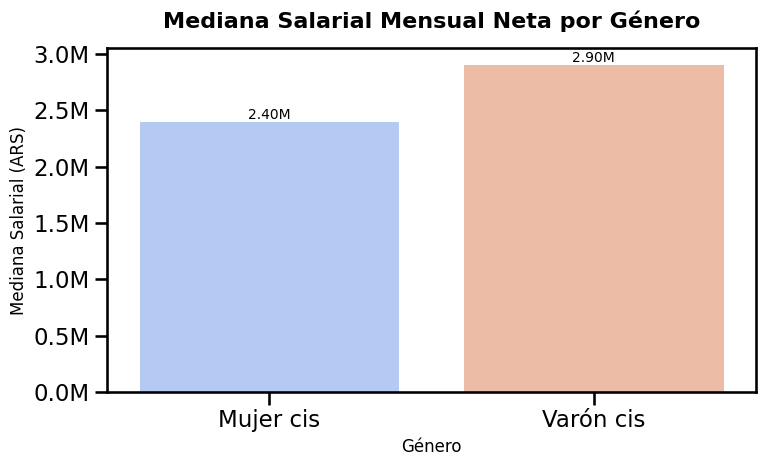

In [32]:
tabla_mediana_genero = (
    df_gender
    .groupby("profile_g")["salary_monthly_NETO"]
    .median()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=tabla_mediana_genero,
    x="profile_g",
    y="salary_monthly_NETO",
    hue="profile_g",
    legend=False,
    palette="coolwarm",
    ax=ax
)

ax.yaxis.set_major_formatter(ticker.FuncFormatter(salary_formatter_m))
ax.set_title("Mediana Salarial Mensual Neta por Género", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Género", fontsize=12)
ax.set_ylabel("Mediana Salarial (ARS)", fontsize=12)

for i, row in tabla_mediana_genero.iterrows():
    ax.text(i, row["salary_monthly_NETO"], f'{row["salary_monthly_NETO"]*1e-6:.2f}M',
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

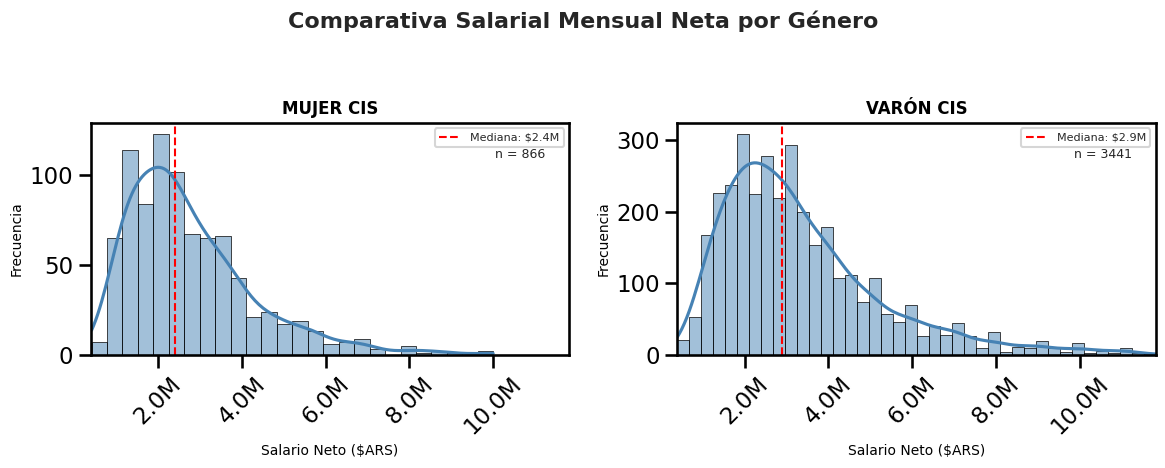

In [37]:
# Visualizacion comparativa de la distribucion salarial neta entre mujeres y varones

# Filtrado del dataset
df_gender = df_restricted[
    df_restricted['profile_g'].isin(['Mujer cis', 'Varón cis'])
].copy()

# Orden de los grupos
top_2_gender = ['Mujer cis', 'Varón cis']

# Configuracion de la matriz
rows, cols = 1, 2
fig, axes = plt.subplots(rows, cols, figsize=(12, 5))

# Aplanado de ejes
axes_flat = axes.flatten()

sns.set_style("whitegrid", {'axes.grid': True, 'grid.color': '.95'})

def salary_formatter_m(x, pos):
    millions = x * 1e-6
    return f'{millions:.1f}M' if x != 0 else '0'

# Para que ambos gráficos tengan la misma escala en X
xmin = df_gender['salary_monthly_NETO'].min()
xmax = df_gender['salary_monthly_NETO'].max()

# Iteraciones sobre los grupos
for i, gender in enumerate(top_2_gender):
    ax = axes_flat[i]
    data_gender = df_gender[df_gender['profile_g'] == gender]['salary_monthly_NETO']

    sns.histplot(
        data_gender,
        kde=True,
        color='steelblue',
        edgecolor='black',
        linewidth=0.5,
        ax=ax
    )

    # Mediana
    median_val = data_gender.median()
    ax.axvline(
        median_val,
        color='red',
        linestyle='--',
        linewidth=1.5,
        label=f'Mediana: ${median_val*1e-6:.1f}M'
    )

    # Formateo
    ax.set_xlim(xmin, xmax)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(salary_formatter_m))
    ax.tick_params(axis='x', rotation=45)

    ax.set_title(f'{gender.upper()}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Salario Neto ($ARS)', fontsize=10)
    ax.set_ylabel('Frecuencia', fontsize=10)

    ax.text(
        0.95, 0.85, f'n = {len(data_gender)}',
        transform=ax.transAxes,
        fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7),
        horizontalalignment='right'
    )
    ax.legend(fontsize=8)

plt.suptitle('Comparativa Salarial Mensual Neta por Género', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Género por Seniority

In [33]:
orden_seniority = ["Junior", "Semi-Senior", "Senior"]

df_gender_seniority = df_restricted[
    (df_restricted["profile_g"].isin(["Varón cis", "Mujer cis"])) &
    (df_restricted["work_seniority"].isin(orden_seniority))
].copy()

print(df_gender_seniority["work_seniority"].value_counts())
print(df_gender_seniority["profile_g"].value_counts())

work_seniority
Senior         2514
Semi-Senior    1349
Junior          444
Name: count, dtype: int64
profile_g
Varón cis    3441
Mujer cis     866
Name: count, dtype: int64


In [34]:
tabla_seniority_genero = (
    df_gender_seniority
    .groupby(["work_seniority", "profile_g"])["salary_monthly_NETO"]
    .agg(
        n="count",
        media="mean",
        mediana="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75)
    )
    .round(2)
    .reset_index()
)

print(tabla_seniority_genero)

  work_seniority  profile_g     n       media    mediana        q25  \
0         Junior  Mujer cis   123  1715839.24  1506450.0  1160500.0   
1         Junior  Varón cis   321  1794311.39  1508000.0  1140000.0   
2    Semi-Senior  Mujer cis   329  2326724.21  2105000.0  1500000.0   
3    Semi-Senior  Varón cis  1020  2671643.74  2428590.0  1800000.0   
4         Senior  Mujer cis   414  3416750.96  3161453.5  2200000.0   
5         Senior  Varón cis  2100  3908599.05  3500000.0  2453214.0   

          q75  
0  2078370.00  
1  2200000.00  
2  2834000.00  
3  3200000.00  
4  4231891.19  
5  4900000.00  


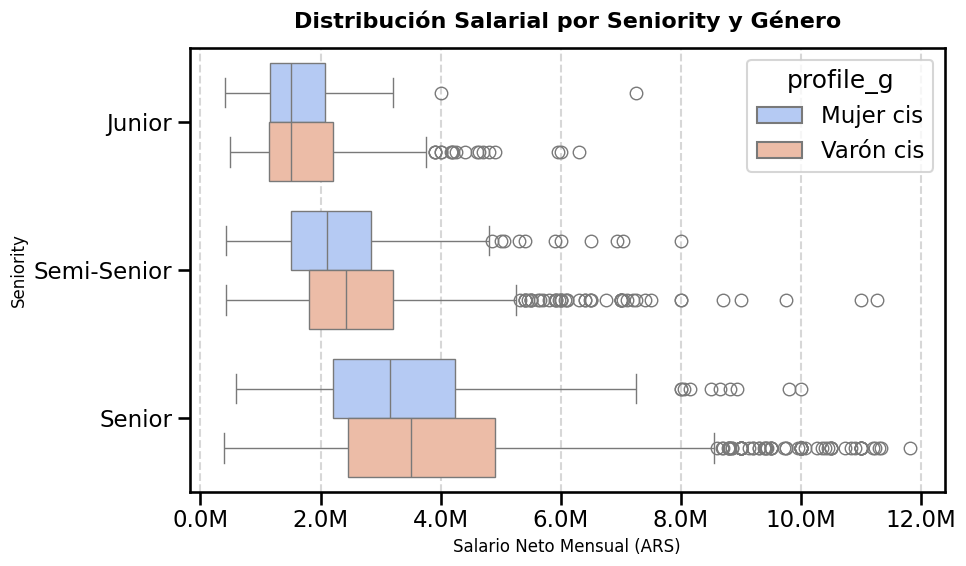

In [35]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df_gender_seniority,
    x="salary_monthly_NETO",
    y="work_seniority",
    hue="profile_g",
    order=orden_seniority,
    palette="coolwarm",
    ax=ax
)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(salary_formatter_m))
ax.set_title("Distribución Salarial por Seniority y Género", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Salario Neto Mensual (ARS)", fontsize=12)
ax.set_ylabel("Seniority", fontsize=12)
ax.grid(True, axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

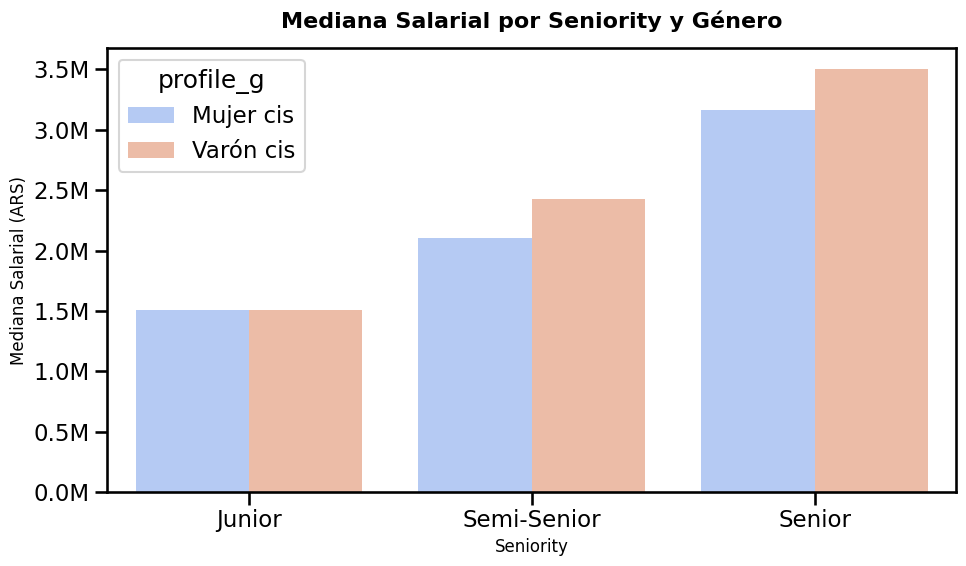

In [36]:
tabla_mediana_seniority = (
    df_gender_seniority
    .groupby(["work_seniority", "profile_g"])["salary_monthly_NETO"]
    .median()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=tabla_mediana_seniority,
    x="work_seniority",
    y="salary_monthly_NETO",
    hue="profile_g",
    order=orden_seniority,
    palette="coolwarm",
    ax=ax
)

ax.yaxis.set_major_formatter(ticker.FuncFormatter(salary_formatter_m))
ax.set_title("Mediana Salarial por Seniority y Género", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Seniority", fontsize=12)
ax.set_ylabel("Mediana Salarial (ARS)", fontsize=12)

plt.tight_layout()
plt.show()